#Logistic Regression for Sentiment Analysis

This notebook implements a Logistic Regression Model for sentiment of analysis of product reviews.

## Project Overview
This project focuses on sentiment analysis of product reviews. We classify reviews into negative, neutral, and positive categories and compare multiple models.
The overall task is to predict whether each review is:
- `0` = negative
- `1` = neutral
- `2` = positive

## Clone GitHub Repository

In [1]:
!git clone https://github.com/Liny-sia/nlp-group-17.git

Cloning into 'nlp-group-17'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 66 (delta 25), reused 35 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 1.58 MiB | 15.16 MiB/s, done.
Resolving deltas: 100% (25/25), done.


## Import Libraries
We import the necessary libraries needed for Logistic Regression

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Dataset
#### Loading the Dataset


In [3]:
import pandas as pd

df = pd.read_csv("/content/nlp-group-17/dataset/AllProductReviews.csv")
df.head()

,ReviewTitle,ReviewBody,ReviewStar,Product
0,Honest review of an edm music lover\n,No doubt it has a great bass and to a great ex...,3,boAt Rockerz 255
1,Unreliable earphones with high cost\n,"This earphones are unreliable, i bought it be...",1,boAt Rockerz 255
2,Really good and durable.\n,"i bought itfor 999,I purchased it second time,...",4,boAt Rockerz 255
3,stopped working in just 14 days\n,Its sound quality is adorable. overall it was ...,1,boAt Rockerz 255
4,Just Awesome Wireless Headphone under 1000...😉\n,Its Awesome... Good sound quality & 8-9 hrs ba...,5,boAt Rockerz 255


#### Cleaning the Dataset

In [4]:
df = df.rename(columns={
    "ReviewBody": "reviewText",
    "ReviewStar": "overall"
})

# Keep only the needed column
df = df[["reviewText", "overall"]]

# Remove the missing values (if exists)
print("")
print(df[["reviewText", "overall"]].isnull().sum())
df = df.dropna(subset=["reviewText", "overall"])

print("")
print(f"Dataset: \n{df.head()}")


reviewText    0
overall       0
dtype: int64

Dataset: 
                                          reviewText  overall
0  No doubt it has a great bass and to a great ex...        3
1  This  earphones are unreliable, i bought it be...        1
2  i bought itfor 999,I purchased it second time,...        4
3  Its sound quality is adorable. overall it was ...        1
4  Its Awesome... Good sound quality & 8-9 hrs ba...        5


## Convert Ratings to Sentiment Labels

This step converts the original 1 – 5 star ratings into 3 sentiment classes:

In [5]:
def convert_rating_to_label(rating):  # Convert the rating to Negative, Neutral, and Positive
    if rating in [1, 2]:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

#### Apply the Sentiment Label Coversion
This creates a new column called `label`, which is what the model will learn to predict.

In [6]:
df["label"] = df["overall"].apply(convert_rating_to_label)
print(df.head(2))

                                          reviewText  overall  label
0  No doubt it has a great bass and to a great ex...        3      1
1  This  earphones are unreliable, i bought it be...        1      0


## Check Label Distribution

In [7]:
label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label_counts = df["label"].value_counts().sort_index()
label_counts_named = label_counts.rename(index=label_names)

print(label_counts_named)

label
negative    3432
neutral     1503
positive    9402
Name: count, dtype: int64


## Split dataset

We split the datset into 3 parts:

- **Training set**: used to train the model
- **Validation set**: used to tune/check the model during development
- **Test set**: used at the end to measure final performance

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df["reviewText"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train size:", len(X_train))
print("X_test size:", len(X_test))
print("X_val size:", len(X_val))

X_train size: 11469
X_test size: 1434
X_val size: 1434


## TF-IDF Vectorisation


In [9]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

## Train Logistic Regression Model

In [10]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## Make Predictions

In [11]:
y_pred = lr_model.predict(X_test_tfidf)

## Evaluate Model

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8165969316596932


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77       343
           1       0.31      0.06      0.10       151
           2       0.85      0.95      0.90       940

    accuracy                           0.82      1434
   macro avg       0.64      0.60      0.59      1434
weighted avg       0.77      0.82      0.78      1434



## Confusion Matrix


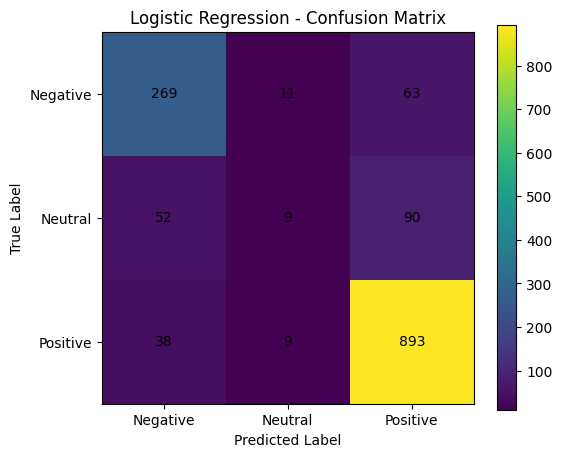

In [14]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Logistic Regression - Confusion Matrix")
plt.colorbar()
classes = ["Negative", "Neutral", "Positive"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Conclusion

The Logistic Regression model performed well for sentiment classification using TF-IDF features. The model was able to classify negative, neutral, and positive reviews with good accuracy.
